# Downloading and managing data with MADAS

For our tutorial, we will use data from [NOMAD](https://nomad-lab.eu). NOMAD is a free and FAIR online database of materials-science data, including results from both theory and experiments. As such, it is a rich source of data for analytics and machine learning.  

NOMAD follows a user-centric approach to data management, allowing users to upload raw data, which is then transformed and archived on the NOMAD platform. As such, it supports many different ways of representing data, including user-defined schemas. This rich metadata is a valuable source for data analytics, as it allows to keep track of the whole provenance of the data, allowing to find and understand outliers and creating trustable results. However, the verbosity of the schemata leads to significant complexity, making it hard to find the relevant information for a given application. Furthermore, the flexible approach of the NOMAD data schema allows that the central database contains different versions of the same schema, based on when the data was processed. While in those cases the data provenance is preserved, bringing the data to an application may require processing of the data before it can be used.

MADAS as a framework allows to connect to the NOMAD API, download data, store it in a local database, apply transformations to the data, and extract the transformed data for downstream applications.

In this tutorial you are going to learn how to:

<div class="alert alert-block alert-warning">
    
**[Use an API to download data](#Use-an-API-to-download-data)**  
**[Store materials data in a local database](#Store-materials-data-in-a-local-database)**  
**[Derive properties in the database](#Derive-properties-in-the-database)**  
**[Retrieve properties](#Retrieve-properties)**  

</div>

Let's get started!

## Use an API to download data

The first step of downloading data is to select a suitable dataset. Within MADAS, we can query the NOMAD database for suitable entries. This is achieved by connecting to the NOMAD API, and submitting queries and downloading data from there.  
If you want to learn more about how NOMAD makes this possible, you can find more information in the [NOMAD documentation](https://nomad-lab.eu/prod/v1/docs/howto/manage/program/api.html).

First we import the API interface for NOMAD:

In [1]:
from madas.apis import NOMAD_API

You can find the full documentation of the NOMAD API class [here](https://madas.readthedocs.io/en/latest/APIs/nomad_archive_api.html).

The most important functions are `get_calculations_by_search` and `get_calculation`. The former allows to query the NOMAD database and downloading all matching entries as `Material` objects ([see also the documentation here](https://madas.readthedocs.io/en/latest/modules/material.html)). Materials will be uniquely identified by their entry id.  
If you already know the entry ids of the NOMAD entries that you are interested in, `get_calculation` can be used to retrieve this entry.

To demostrate how this works with MADAS, we have selected a high-throughput dataset [1] computed using the hybrid HSE06 exchange-correlation functional with density functional theory [from NOMAD](https://dx.doi.org/10.17172/NOMAD/2025.05.01-1). To limit the amount of retrieved data, we restrict our search to cubic structures.  
To simplify writing NOMAD queries, it is possible to create them via [the GUI](https://nomad-lab.eu/prod/v1/gui/search/entries) (see also [this section](https://nomad-lab.eu/prod/v1/docs/tutorial/explore.html) of the NOMAD documentation), and copying the query by clicking on the **<>** symbol below the search bar.

In [2]:
# Create an API object
api = NOMAD_API()

In [3]:
# define the NOMAD query
query = {
    "results.material.symmetry.crystal_system:any": [
      "cubic"
    ],
    "results.method.simulation.dft.xc_functional_type:any": [
      "hybrid"
    ],
    "datasets.dataset_name:any": [
      "Materials Database from All-electron Hybrid Functional DFT Calculations"
    ],
    "results.properties.available_properties:all": [
      "dos_electronic"
    ]
  }

We can test if our query worked by downloading only a single calculation at first:

In [4]:
materials = api.get_calculations_by_search(query, max_entries=1)

Found 10 entries
Possibly not all entries discovered due to max_entries limit
Finished download.


Let's investigate what we got back from the API:

In [5]:
example_material = materials[0]
print(example_material)

Material(mid = -mwuLAwRgIeJRgL3CXOYvJvu9G-g, formula = Al4Ca2, data = {'archive'}, properties = set())


Printing the `Material` reveals some of it's properties:  
- the `mid` is used to uniquely identify the material. It is obtained from the NOMAD _entry id_.  
- the `formula` is the reduced formula and can be used as a human readable identifier when working with the data.  
- the `data` attribute contains all data that was downloaded from NOMAD.  
- the `property` attribute is still empty, as it contains properties that are derived from the downloaded `data`.  


We can verify that we recieved the same data by creating a link to the NOMAD website with the entry id:  

In [6]:
print(f"https://www.nomad-lab.eu/entry/id/{example_material.mid}")

https://www.nomad-lab.eu/entry/id/-mwuLAwRgIeJRgL3CXOYvJvu9G-g


We can visualize the unit cell of the material using some untility functions:

In [7]:
from madas.plotting import plot_material

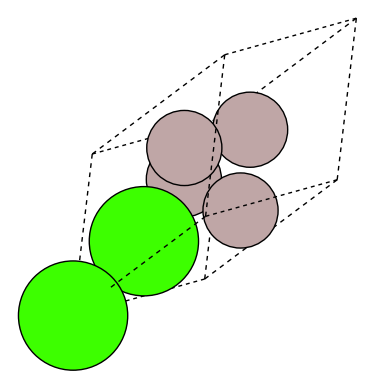

In [8]:
plot_material(example_material,
              repeat=[1,1,1], # repetitions of the unit cell 
              show_unit_cell=2) # show the whole unit cell in the plot

MADAS uses the [Atomic Simulation Environment (ASE)](https://ase-lib.org/) for representing atomic structures (and much more). The `ase.Atoms` object of each `Material` can be used to extract it directly and get access to many convenient functions of the `ase` famework.

In [9]:
print(type(example_material.atoms))

<class 'ase.atoms.Atoms'>


Let's inspect the `data` attibute. For the API, we have recieved the _archive_ as a Python dictinary:

In [10]:
print(example_material.data.keys())

dict_keys(['archive'])


Within the archive, we find the information NOMAD has stored about this entry:

In [11]:
print(example_material.data['archive'].keys())

dict_keys(['processing_logs', 'run', 'workflow2', 'metadata', 'results', 'm_ref_archives'])


The material properties are currently emtpy:

In [12]:
print(example_material.properties)

{}


MADAS provides a convenient way of accessing the information stored in the `data` and `properties` attributes of a `Material`. As an example, we can find the reduced formula in the NOMAD archive.  
This information can be extracted from the `Material` object by specifying the path as follows:

In [13]:
example_material.get_data_by_path('archive/run/0/system/0/chemical_composition_reduced')

'Al2Ca'

You can use a different path to extract any information from the `data` of a `Material`. Similarly, for `properties`, `Material.get_property_by_path()` can be used.

More information on how to work with the NOMAD API most efficiently can be found in the tutorial about [using the NOMAD API](https://madas.readthedocs.io/en/latest/tutorials/4_NOMAD_API_usage.html).

Now, running `get_calculations_by_search` will return a `list` of `Material` objects. To store these on our machine, we will make use of a database.

## Store materials data in a local database

First, import the `MaterialsDatabase` class:

In [14]:
from madas import MaterialsDatabase

and create a `MaterialsDatabase` object. Here we specify the `filepath`, which tells the database where to store the information on our local machine. Furthermore, we pass it the the `NOMAD_API` object. Note that the default API of the `MaterialsDatabase` is also the NOMAD API.

In [15]:
db = MaterialsDatabase(filename='materials_database.db', api = api, log_mode='silent')

Initially, the database is emtpy:

In [16]:
print(len(db))

0


Using the function `fill_database` will call the `get_calculations_by_search` function of the `NOMAD_API`. We therefore pass it the `query`, and it will automatically download all entries it can find with this query and store them in a local file.  
This may take some minutes based on your internet connection and the availability of the remote server.

In [17]:
db.fill_database(query, rate_limit=0.5)

The actual file handling is done using a `Backend` class, which can be any type of storage.  
For more information, see also the [Backend documentation page](https://madas.readthedocs.io/en/latest/modules/backend.html), and in the [tutorial for creating a custom Backend](https://madas.readthedocs.io/en/latest/tutorials/5_custom_Backend.html).

During the processing of the query, the `MaterialsDatabase` writes some log entries. These can be very useful for debugging and for finding failing entries when large or long queries are processed. 
You can set where these messages are written (to the terminal and/or) to file) by using the `log_mode` attribute when crating the `MaterialsDatabase` object.
You can inspect the log file by using the `MaterialsDatabase.log_file_path` attribute. 

In [18]:
with open(db.log_file_path, 'r') as f_: # open the log file for reading
    logfile=f_.readlines() # read the log files line by line

print(''.join(logfile[:5])) # print the last 5 log entries
print('...')
print(''.join(logfile[-5:])) # print the last 5 log entries

2026-07-28 11:40:50,723 - materials_database_log - INFO - Retrieving data...
2026-07-28 11:40:53,796 - materials_database_api - INFO - Found 191 entries
2026-07-28 11:40:53,796 - materials_database_api - INFO - Download data for 191 entries
2026-07-28 11:43:10,278 - materials_database_api - INFO - Finished download.
2026-07-28 11:43:10,279 - materials_database_api - ERROR - Could not get calculation J2nc2lcX-WrQk0ADw9KrrdbLZ9QU, because of error 'data' with traceback Traceback (most recent call last):

...
2026-07-28 11:43:15,718 - materials_database_api - INFO - Wrote material with id -mwuLAwRgIeJRgL3CXOYvJvu9G-g.
2026-07-28 11:43:15,751 - materials_database_api - INFO - Wrote material with id IG_peLrfHu1wFotfie5hHikSIv9S.
2026-07-28 11:43:15,792 - materials_database_api - INFO - Wrote material with id cAUFbd6qigJX7dN0xT0qGZFnU1vl.
2026-07-28 11:43:15,806 - materials_database_api - INFO - Wrote material with id nrkRnMTUzJplcSCosQ_P9GJzW4S3.
2026-07-28 11:43:15,836 - materials_database

After downloading, the database contains all entries that were found:

In [19]:
len(db)

146

Sometimes the download does not work for all entries due to different reasons, such as connection problems or bandwidth problems of the remote database. You can see from the logs how many entries the dataset contained. In the best case, the database contains all entries from the dataset. If not, the `MaterialsDatabase` implelements a `retry_download` method, to automatically retry the download of these entries.

In [20]:
db.retry_download(rate_limit=0.5)

Now the length of the database and the number of entries in the dataset should be the same:

In [21]:
len(db)

191

We can get every entry of the database in the order they have been added by using the index:

In [22]:
db[0]

Material(mid = uw_q33Fk3O1qmMezl9ondH9DYs-H, formula = Al12Mo, data = {'archive'}, properties = set())

Or by using the `mid` of the `Material` object we want to recover.

In [23]:
db[db[0].mid]

Material(mid = uw_q33Fk3O1qmMezl9ondH9DYs-H, formula = Al12Mo, data = {'archive'}, properties = set())

When we inspect these material in our database, we see they contain the full archive. However, we want to make the data easier accessible. To do so, we will see next how to manipulate data in the database.

## Derive properties in the database

To access properties in the database, we can just iterate over its elements. Because this can take some time, especially for larger databases, we will use [tqdm](https://tqdm.github.io/) for showing progress bar. MADAS provides a wrapper for tqdm that automatically selects the correct layout of the progress bar, both in a notebook and the command line.

In [24]:
from madas.utils import tqdm

Then, we can access the information in each `Material`. As an example, we will compute the volume of the unit cell using the `ase.Atoms` objects. Note that this information is also contained in the `data` property, as NOMAD also computes the unit cell volume.

In [25]:
volumes = [] # create an empty list for our volumes
for entry in tqdm(db): # for every entry in the database
    volume = entry.atoms.get_volume() # compute the volume
    volumes.append(volume) # append it to the volume list

  0%|          | 0/191 [00:00<?, ?it/s]

Already with this information, we can create a histogram that describes our data. We use [matplotlib](https://matplotlib.org/) for the visualization;

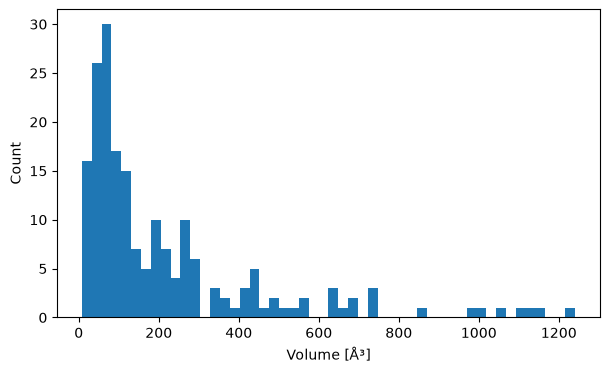

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.hist(volumes, bins=50)
plt.xlabel('Volume [Å³]')
plt.ylabel('Count')
plt.show()

We can see a distribution of volumes with a peak around 100 Å³ and few entries with higher volumes.

Let's find some more useful information. For this, we will explore what is contained in the NOMAD archives that we have downloaded.  
To do so, MADAS provides some usefull utilities:

In [27]:
from madas.utils import print_key_paths, resolve_nested_dict

The first function, `print_key_paths`, can be used to print all paths that a key in a nested dictionary has. This can help discovering the location of a specific information in the data.  
We pick a specific example for illustration purposes:

In [28]:
example_material = db["2KE2kVq3XhM1eU67AsxN890ohcop"]

Then, we search for the band gap in the data of the example material:

In [29]:
print_key_paths('band_gap', example_material.data)

/archive/run/0/calculation/0/band_gap
/archive/run/0/calculation/0/dos_electronic/0/band_gap
/archive/run/0/calculation/0/band_structure_electronic/0/band_gap
/archive/results/properties/electronic/band_gap
/archive/results/properties/electronic/dos_electronic_new/0/data/0/band_gap
/archive/results/properties/electronic/band_structure_electronic/0/band_gap


We see several paths: 
- The first three paths point to the _run_ section of the archive, which is where data that the NOMAD parsers extract from calculations is stored.  
- The second three paths point to the _results_ section, which is used to aggregate information for the NOMAD GUI.  

We can use that aggregated data. To do so, we first inspect its contents with `resolve_nested_dict`, which follows the specified path and returns the data at the end:

In [30]:
resolve_nested_dict(example_material.data, 'archive/results/properties/electronic/band_gap')

[{'index': 0,
  'value': 2.307134352960001e-19,
  'energy_highest_occupied': -1.07345834478e-18,
  'energy_lowest_unoccupied': -8.427449094839999e-19,
  'provenance': {'label': 'dos',
   'dos': '#/run/0/calculation/0/dos_electronic/0/total/0'}},
 {'index': 0,
  'value': 2.3181573282019203e-19,
  'type': 'direct',
  'energy_highest_occupied': -1.0737309038646226e-18,
  'energy_lowest_unoccupied': -8.419151710444306e-19,
  'provenance': {'label': 'band_structure',
   'band_structure': '#/run/0/calculation/0/band_structure_electronic/0/segment/0'}}]

We can see that NOMAD stores the band gap value, the highest occupied, and the lowest unoccupied electronic state. Furthermore, there are two possible values of the gap: one is extracted from the band structure, one from the DOS. We choose the value from the DOS, because we also use the DOS in later tutorials. Thereby, we keep the data consistent.
Finally, we notice that this data is provided in Joules, and we can transform it to a more accessible unit.  
First, we extract the gap data, a dictionary, from the list:

In [31]:
gap_data = resolve_nested_dict(example_material.data, 'archive/results/properties/electronic/band_gap')

Then we compute the gap and transform the unit to eV:

In [32]:
from scipy.constants import electron_volt

gap = None
for gap_info in gap_data:
    if gap_info['provenance']['label']=='dos':
        gap = gap_info['value']/ electron_volt
print(gap)

1.4400000000000006


We can write a small function to apply the same transformation to all entries:

In [33]:
def get_gap(material) -> float:
    gap_data = resolve_nested_dict(material.data, 'archive/results/properties/electronic/band_gap')
    gap = None
    for gap_info in gap_data:
        if gap_info['provenance']['label']=='dos':
            gap = gap_info['value']/ electron_volt
    if gap is None:
        raise ValueError('Could not find gap from DOS')
    return gap

And extract these values:

In [34]:
band_gaps = []
for entry in tqdm(db):
    band_gaps.append(get_gap(entry))

  0%|          | 0/191 [00:00<?, ?it/s]

We can plot the data:

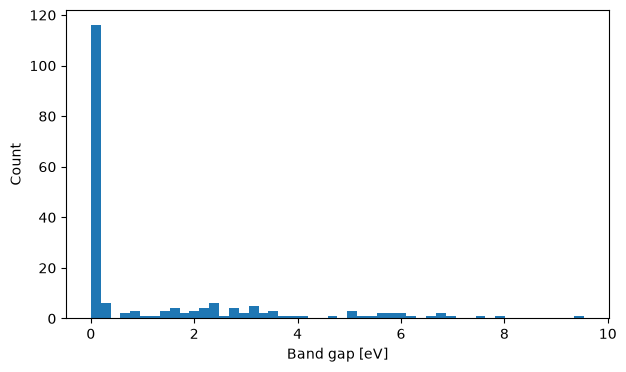

In [35]:
plt.figure(figsize=(7,4))
plt.hist(band_gaps, bins=50)
plt.xlabel('Band gap [eV]')
plt.ylabel('Count')
plt.show()

Here we see a large peak for small or no band gap, and a long flat distribution of band gaps up until 10 eV.

Now that we have extacted both volumes and band gaps, we can plot them together:

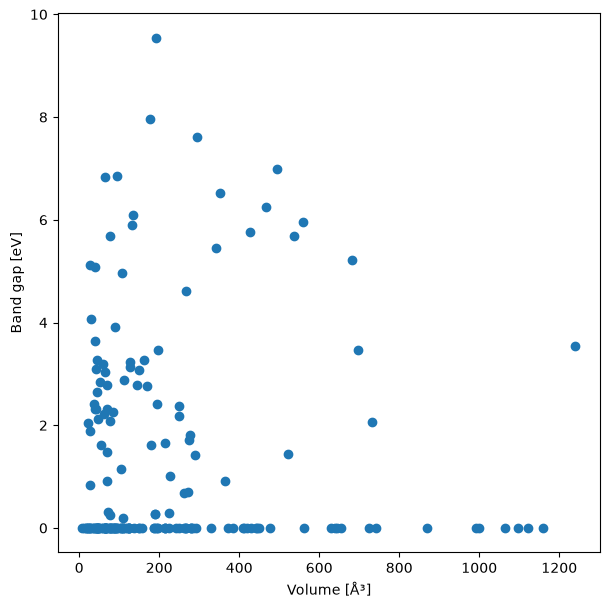

In [36]:
plt.figure(figsize=(7,7))
plt.scatter(volumes, band_gaps)
plt.xlabel('Volume [Å³]')
plt.ylabel('Band gap [eV]')
plt.show()

There seems to be not very much correlation between those quantities.

We can derive many useful qantities from the data in our database. But, in some cases, the generation of these quantites may take long, or we want to first create the quantity and then process it further later on, without having to bring the necessary code. For these cases, it is possible to update the data in the database using functions. Here, we will add these two quantites to our database. At the moment, the entries only contain the data we downloaded:

In [37]:
print(db[0])

Material(mid = uw_q33Fk3O1qmMezl9ondH9DYs-H, formula = Al12Mo, data = {'archive'}, properties = set())


We can use the function `update_derived_properties` of the database to update our entries. It takes a list of property names and a list of functions that are used to derive these properties as inputs.

In [38]:
db.update_derived_properties(
    [
        'band_gap', 
        'volume'
    ],
    [
        get_gap, # we defined this function above
        lambda entry: entry.atoms.get_volume() # this is a lambda expression
    ]
)

For the band gaps, we use the existing function, for the volume (because it requires very little instructions), we can use a Python lambda expression, i.e., an unnamed function that is defined only where it is executed.

Now, the `properties` of our entries have been updated:

In [39]:
db[0]

Material(mid = uw_q33Fk3O1qmMezl9ondH9DYs-H, formula = Al12Mo, data = {'archive'}, properties = {'volume', 'band_gap'})

For many applications, the data should be available as lists, arrays, or [Pandas](https://pandas.pydata.org/) dataframes. We can extract these from a MADAS `MaterialsDatabase`.

## Retrieve properties

Properties can be retrieved by name:

In [40]:
band_gaps = db.get_properties('band_gap')

  0%|          | 0/191 [00:00<?, ?it/s]

For dataframes, we can use another function:

In [41]:
df = db.get_property_dataframe(['volume', 'band_gap'])

In [42]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [43]:
df.describe()

,volume,band_gap
count,191.000000,191.000000
mean,217.414811,1.255602
std,246.428808,2.051329
min,7.709944,0.000000
25%,64.001745,0.000000
50%,114.783390,0.000000
75%,269.220632,2.195000
max,1240.477268,9.540000


We can also pass a property or data path to the function to obtain the property directly:

In [44]:
db.get_property_dataframe(['volume', 'band_gap', 'archive/results/material/chemical_formula_reduced'])

,volume,band_gap,archive/results/material/chemical_formula_reduced
uw_q33Fk3O1qmMezl9ondH9DYs-H,214.318319,0.0,Al12Mo
N_rrutGbCm4lbYzOYYw_xrlDszxL,74.849999,0.0,BaInO3
0DUM1fhSuwC0YOk2keyE6Kxsq0qf,158.195074,0.0,Ba3OSn
NkZcM91rv7HpAzbKYVeU1CfF8IUx,160.854354,3.27,CdGa2O4
v2czgvKB67oi9BcMK-PbDhtiav_z,363.831005,0.91,CoSb3
...,...,...,...
OWiTzBb3ydhhAu1EnuwAYxdsJpon,278.273676,0.0,CuTe2
1MxLLV_N-LSsKhd_1THpn1ZhW4NN,191.867383,0.0,Co3S4
J2nc2lcX-WrQk0ADw9KrrdbLZ9QU,75.964842,2.08,Cu2O
dFvfjl5R8kRN6JE4sTiofe6c51Tm,430.555306,0.0,AsCu3


## References

**[1]** Akhil S. Nair, Lucas Foppa, and Matthias Scheffler   
_Materials Database from All-electron Hybrid Functional DFT Calculations_.  
_Sci Data_ *12*, 1518 (2025). https://doi.org/10.1038/s41597-025-05867-z